In [44]:
import numpy as np
import random
import matplotlib.pyplot as plt
from numba import njit
import time
from IPython.display import HTML

In [45]:
class IsingModel:
    def __init__(self, N, J, beta, B, M):
        self.N = N
        self.J = J
        self.beta = beta
        self.B = B
        self.M = M
        self.spins = None
    def spin(self):
        self.spins = np.random.choice([-1, 1], size=(self.N, self.N))
    def energy_change(self, i , j):
        s=self.spins[i, j]
        neighbors_sum = self.spins[(i-1)%self.N, (j-1)%self.N] + self.spins[(i-1)%self.N, j] + self.spins[(i-1)%self.N, (j+1)%self.N] + self.spins[i, (j-1)%self.N] + self.spins[i, (j+1)%self.N] + self.spins[(i+1)%self.N, (j-1)%self.N] + self.spins[(i+1)%self.N, j] + self.spins[(i+1)%self.N, (j+1)%self.N]
        dE= 2 * s * (self.J * neighbors_sum + self.B)
        return dE
    def energy(self):
        E=0
        for i in range(self.N):
            for j in range(self.N):
                s = self.spins[i, j]
                neighbors_sum = self.spins[(i-1)%self.N, (j-1)%self.N] + self.spins[(i-1)%self.N, j] + self.spins[(i-1)%self.N, (j+1)%self.N] + self.spins[i, (j-1)%self.N] + self.spins[i, (j+1)%self.N] + self.spins[(i+1)%self.N, (j-1)%self.N] + self.spins[(i+1)%self.N, j] + self.spins[(i+1)%self.N, (j+1)%self.N]
                E += -self.J * s * neighbors_sum - self.B * s
        return E/2
    def metropolis_step(self):
        for s in range(self.N*self.N):
            i=np.random.randint(0, self.N)
            j=np.random.randint(0, self.N)
            dE = self.energy_change(i, j)
            if dE < 0:
                self.spins[i, j] *= -1
            elif random.random() < np.exp(-self.beta * dE):
                self.spins[i, j] *= -1
    def magnetization(self):
        m = 1/(self.N*self.N) * np.sum(self.spins)
        return m
    def simulate(self):
        energy_record = []
        magnetization_record = []
        spins_record = []
        for step in range(self.M):
            self.metropolis_step()
            energy_record.append(self.energy())
            magnetization_record.append(self.magnetization())
            spins_record.append(self.spins.copy())
        return energy_record, magnetization_record, spins_record


In [46]:
model = IsingModel(N=4, J=1.0, beta=0.4, B=0.0, M=1000)
model.spin()
print(model.energy())
print(model.energy_change(1, 1))
model.metropolis_step()

-4.0
4.0


In [ ]:
model = IsingModel(N=100, J=1.0, beta=0.4, B=0.0, M=100)
model.spin()  # inicjalizacja losowej siatki
E, M, S = model.simulate()

print(f"Energia: {E[-1]}")
print(f"Magnetyzacja: {M[-1]}")
print(f"Liczba zapisanych stanów: {len(S)}")

Energia: -36296.0
Magnetyzacja: -0.0284
Liczba zapisanych stanów: 100


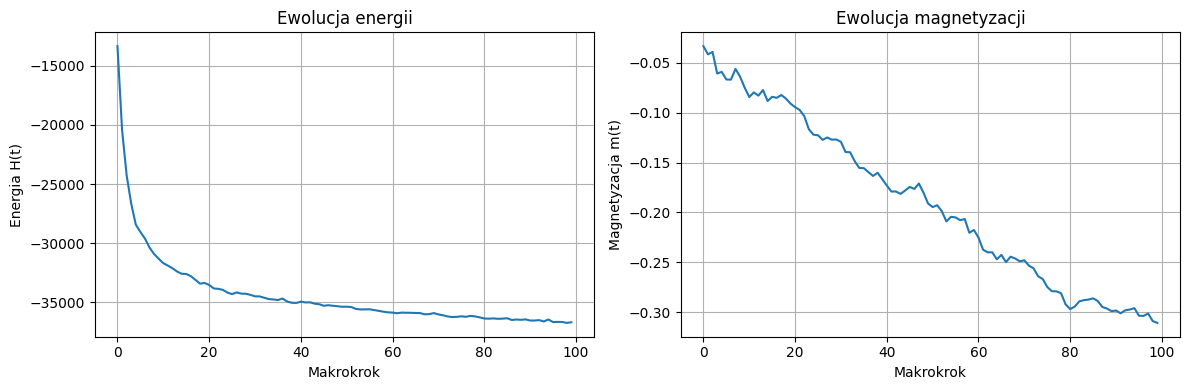

In [ ]:
model.spin()
E, M, S = model.simulate()

# wykres energii
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(E)
plt.xlabel("Makrokrok")
plt.ylabel("Energia H(t)")
plt.title("Ewolucja energii")
plt.grid()

# wykres magnetyzacji
plt.subplot(1, 2, 2)
plt.plot(M)
plt.xlabel("Makrokrok")
plt.ylabel("Magnetyzacja m(t)")
plt.title("Ewolucja magnetyzacji")
plt.grid()

plt.tight_layout()
plt.savefig("wykresy.png")
plt.show()

In [ ]:
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots(figsize=(6, 6))

def update(frame):
    ax.clear()
    ax.imshow(S[frame], cmap='summer', vmin=-1, vmax=1)
    ax.set_title(f"Makrokrok {frame}/{len(S)-1}")
    ax.axis('off')
    return ax,

anim = FuncAnimation(fig, update, frames=len(S), interval=100, repeat=True)
plt.close(fig)
HTML(anim.to_jshtml())

In [52]:
@njit
def energy_change_numba(spins, i, j, N, J, B):
    s=spins[i, j]
    neighbors_sum = spins[(i-1)%N, (j-1)%N] + spins[(i-1)%N, j] + spins[(i-1)%N, (j+1)%N] + spins[i, (j-1)%N] + spins[i, (j+1)%N] + spins[(i+1)%N, (j-1)%N] + spins[(i+1)%N, j] + spins[(i+1)%N, (j+1)%N]
    dE= 2 * s * (J * neighbors_sum + B)
    return dE

@njit
def energy_numba(spins, N, J, B):
    E = 0.0
    for i in range(N):
        for j in range(N):
            s = spins[i, j]
            neighbors_sum = spins[(i-1)%N, (j-1)%N] + spins[(i-1)%N, j] + spins[(i-1)%N, (j+1)%N] + spins[i, (j-1)%N] + spins[i, (j+1)%N] + spins[(i+1)%N, (j-1)%N] + spins[(i+1)%N, j] + spins[(i+1)%N, (j+1)%N]
            E += -J * s * neighbors_sum - B * s
    return E / 2

@njit
def metropolis_step_numba(spins, N, J, beta, B):
    for spin in range(N * N):
        i = np.random.randint(0, N)
        j = np.random.randint(0, N)
        dE = energy_change_numba(spins, i, j, N, J, B)
        if dE < 0:
            spins[i, j] *= -1
        elif np.random.random() < np.exp(-beta * dE):
            spins[i, j] *= -1

@njit
def simulate_numba(spins, N, J, beta, B, M):
    energy_record = np.zeros(M)
    magnetization_record = np.zeros(M)
    
    for step in range(M):
        metropolis_step_numba(spins, N, J, beta, B)
        energy_record[step] = energy_numba(spins, N, J, B)
        magnetization_record[step] = np.sum(spins) / (N * N)
    
    return energy_record, magnetization_record


In [ ]:
N = 50
J = 1.0
B = 0.0
beta = 0.4
M = 200

# stan początkowy
spins = np.random.choice([-1, 1], size=(N, N))

# mierzymy czas dla numba
simulate_numba(spins.copy(), N, J, beta, B, 1)
spins_numba = spins.copy()
t0 = time.perf_counter()
E_numba, M_numba = simulate_numba(spins_numba, N, J, beta, B, M)
t1 = time.perf_counter()

print("Czas wykonania (Numba):", t1 - t0)

# mierzymy czas bez numba 
t0 = time.perf_counter()
energy_py, magnetization_py, spins_py = model.simulate()
t1 = time.perf_counter()

time_python = t1 - t0
print("Czas wykonania (bez Numba):", time_python)

Czas wykonania (Numba): 0.04283319995738566
Czas wykonania (bez Numba): 22.250506700016558
